# Degrees of Freedom, Regularity, and Tangent/Normal Hyperplanes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L08/L08_degrees_of_freedom_and_regularity.ipynb)
### MECH 559 - Systems Optimization - L08

Companion notebook to the "Nonlinear programming" lecture. It works through the geometry that the lecture builds the Lagrangian and KKT theory on: how many degrees of freedom a constrained problem has, what it means for a point to be *regular*, and what the normal and tangent hyperplanes look like at such a point.

## Learning objectives

By the end, students should be able to:

1. Reformulate a general NLP (inequalities + equalities) as an equality-constrained problem by lumping the *active* inequalities with the equalities.
2. Classify a constrained problem by its degrees of freedom $p = n - m$ and explain the three cases $m>n$, $m=n$, $n>m$.
3. Check whether a point is *regular* (constraint qualification holds) by testing whether the active-constraint gradients are linearly independent.
4. Compute the normal hyperplane (span of active-constraint gradients) and the tangent hyperplane (its orthogonal complement) at a regular point, in both 2D and 3D.
5. Recognize, from a concrete example, what goes wrong geometrically at an irregular point - and why that example will resurface when we get to the KKT conditions.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import null_space
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"feasible": "#A8DADC", "boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "other": "#6C5B7B"}

print(f"NumPy {np.__version__}")

NumPy 2.5.0


---
## 1. From a general NLP to $h(x)=0$

The lecture's starting point is

$$
\min_{x\in\mathbb{R}^n} f(x) \quad \text{s.t.} \quad g_j(x)\le 0,\ j=1,\dots,m_i, \qquad \hat h_j(x)=0,\ j=1,\dots,m_e, \qquad l\le x\le u.
$$

*If* we already know which inequalities are active at the solution ($g_A$), we can lump them with the equalities, $h = [g_A\ \ \hat h]^{\mathsf T}$, and (ignoring the box constraints) study the simpler problem

$$
\min_{x\in\mathbb{R}^n} f(x) \quad \text{s.t.} \quad h_j(x)=0,\ j=1,\dots,m.
$$

Everything in this notebook is about the *geometry* of that equality-constrained problem: how many degrees of freedom it has, and what "regular" means at a point on $h(x)=0$. We come back to the *inequality* case (and to not knowing the active set in advance) when the KKT conditions are introduced - see `L08_kkt_conditions.ipynb`.

---
## 2. Degrees of freedom: $m$ vs. $n$

With $m$ functionally independent constraints in $\mathbb{R}^n$, the feasible set generically has $p = n-m$ degrees of freedom:

- $n > m$: the feasible set is a $(n-m)$-dimensional manifold (curve, surface, ...) - the interesting case.
- $n = m$: generically isolated point(s).
- $n < m$: generically no solution at all (over-determined, unless constraints are dependent/redundant).

> **Predict:** start with a single constraint, a circle in $\mathbb{R}^2$ ($m=1$, $n=2$, so 1 DOF - a curve). If you add one more independent line constraint ($m=2=n$), how many isolated feasible points do you expect? If you then add a *second*, generic line ($m=3>n$), do you expect that third constraint to pass through either of those points?

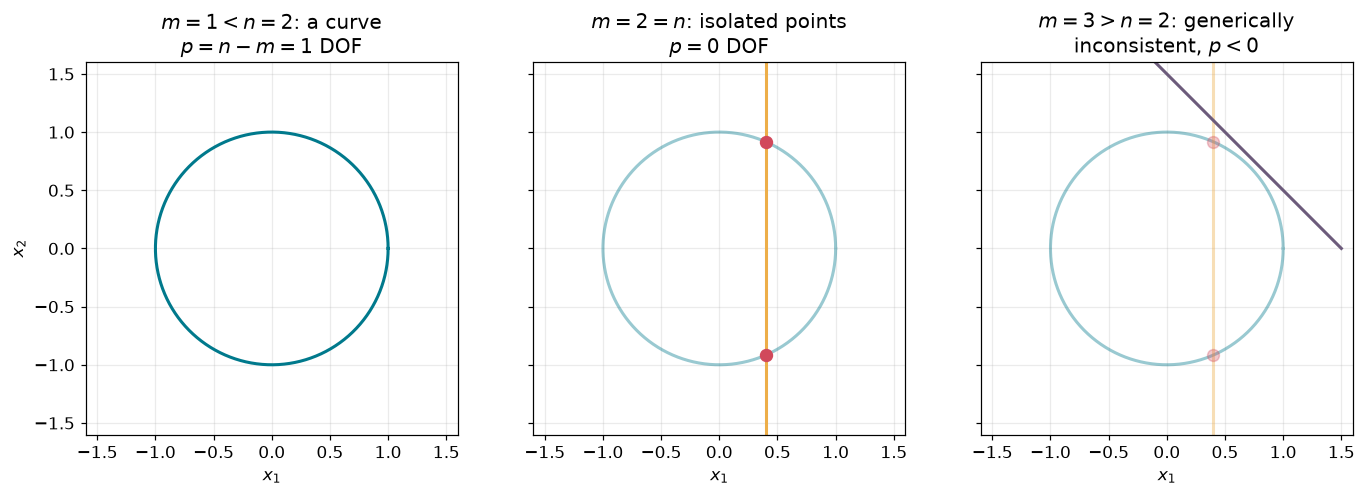

line2(x) evaluated at the two m=2 solutions: -0.183, -2.017
Neither is zero, so the third constraint does NOT pass through either point: the m=3 system is inconsistent.


In [2]:
def circle(x):
    return x[0]**2 + x[1]**2 - 1.0

def line1(x):
    return x[0] - 0.4

def line2(x):
    return x[0] + x[1] - 1.5

theta = np.linspace(0, 2 * np.pi, 400)
circ_x, circ_y = np.cos(theta), np.sin(theta)

# m = 2 = n: circle intersect line1 -> isolated points, solved in closed form
x1_int = 0.4
y1_int = np.sqrt(1 - x1_int**2)
pts_m2 = np.array([[x1_int, y1_int], [x1_int, -y1_int]])

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharex=True, sharey=True)

axes[0].plot(circ_x, circ_y, color=COLORS["boundary"], lw=2)
axes[0].set_title("$m=1<n=2$: a curve\n$p = n-m = 1$ DOF")

axes[1].plot(circ_x, circ_y, color=COLORS["boundary"], lw=2, alpha=0.4)
axes[1].axvline(0.4, color=COLORS["accent"], lw=2)
axes[1].scatter(pts_m2[:, 0], pts_m2[:, 1], color=COLORS["optimum"], zorder=3, s=60)
axes[1].set_title("$m=2=n$: isolated points\n$p=0$ DOF")

xx = np.linspace(-1.5, 1.5, 10)
axes[2].plot(circ_x, circ_y, color=COLORS["boundary"], lw=2, alpha=0.4)
axes[2].axvline(0.4, color=COLORS["accent"], lw=2, alpha=0.4)
axes[2].plot(xx, 1.5 - xx, color=COLORS["other"], lw=2)
axes[2].scatter(pts_m2[:, 0], pts_m2[:, 1], color=COLORS["optimum"], zorder=3, s=60, alpha=0.3)
axes[2].set_title("$m=3>n=2$: generically\ninconsistent, $p<0$")

for ax in axes:
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.6, 1.6)
    ax.set_aspect("equal")
    ax.set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

res1 = line2(pts_m2[0])
res2 = line2(pts_m2[1])
print(f"line2(x) evaluated at the two m=2 solutions: {res1:.3f}, {res2:.3f}")
print("Neither is zero, so the third constraint does NOT pass through either point: the m=3 system is inconsistent.")

The third panel is the deck's $m=3,\,n=2$ "inconsistent" case: three generic curves in the plane essentially never share a common point. The second panel is the $m=n$ "isolated solutions" case, and the first is the $n>m$ case with $p=1$ degree of freedom that the rest of this lecture (reduced gradient, Lagrangian, KKT) is built around.

---
## 3. Regularity and the constraint qualification

A point $x$ is **regular** if the gradients of the active constraints, $\nabla h_j(x)$, $j=1,\dots,m$, are **linearly independent** (this is the *constraint qualification*, LICQ). Equivalently: the Jacobian $J(x)=\nabla h(x)\in\mathbb{R}^{m\times n}$ has full row rank $m$.

> **Predict:** at a point where the boundaries of two active inequality constraints meet *tangentially* (a cusp, rather than crossing transversally), do you expect the two gradients to be independent or parallel?

We reuse the deck's own irregular-point example (Class Exercise 4, Q1):

$$
\min_{x_1,x_2} -x_1 \quad \text{s.t.} \quad g_1(x)=x_2-(1-x_1)^3\le 0,\qquad g_2(x)=-x_2\le 0,
$$

whose constrained optimum is claimed to sit at the non-regular point $x^*=(1,0)$.

In [3]:
def g1(x):
    return x[1] - (1 - x[0])**3

def g2(x):
    return -x[1]

def grad_g1(x):
    return np.array([3 * (1 - x[0])**2, 1.0])

def grad_g2(x):
    return np.array([0.0, -1.0])

x_star = np.array([1.0, 0.0])
J = np.vstack([grad_g1(x_star), grad_g2(x_star)])
rank = np.linalg.matrix_rank(J)

print("Active-constraint Jacobian at x* = (1, 0):")
print(J)
print(f"rank(J) = {rank}  (need rank 2 for LICQ with 2 active constraints -> {'REGULAR' if rank == 2 else 'NOT regular'})")

# Contrast with a nearby point where only g2 is active (g1 strictly satisfied)
x_reg = np.array([0.5, 0.0])
print(f"\nAt x=(0.5, 0): g1(x) = {g1(x_reg):.3f} (inactive), g2(x) = {g2(x_reg):.3f} (active)")
J_reg = grad_g2(x_reg).reshape(1, 2)
print(f"Active-constraint Jacobian there is just grad(g2) = {J_reg.ravel()}, rank = {np.linalg.matrix_rank(J_reg)} -> regular (trivially, only 1 active gradient and it is nonzero).")

Active-constraint Jacobian at x* = (1, 0):
[[ 0.  1.]
 [ 0. -1.]]
rank(J) = 1  (need rank 2 for LICQ with 2 active constraints -> NOT regular)

At x=(0.5, 0): g1(x) = -0.125 (inactive), g2(x) = -0.000 (active)
Active-constraint Jacobian there is just grad(g2) = [ 0. -1.], rank = 1 -> regular (trivially, only 1 active gradient and it is nonzero).


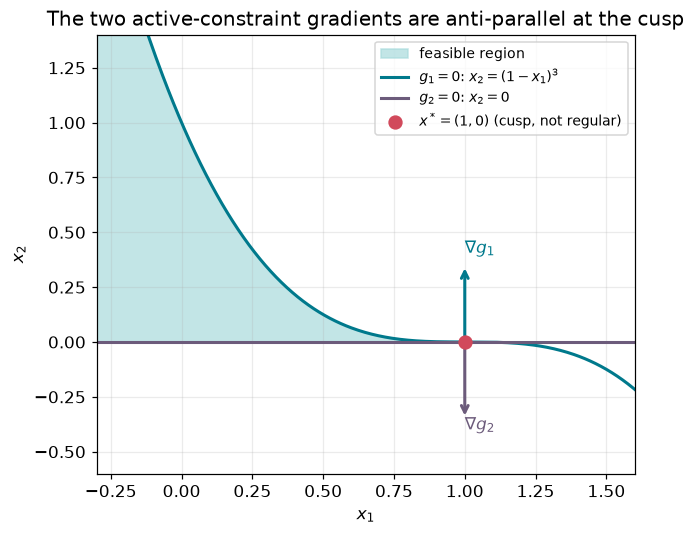

In [4]:
x1_plot = np.linspace(-0.3, 1.6, 400)
g1_boundary = (1 - x1_plot)**3

fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(x1_plot, 0, np.maximum(g1_boundary, 0), where=(g1_boundary >= 0),
                 color=COLORS["feasible"], alpha=0.7, label="feasible region")
ax.plot(x1_plot, g1_boundary, color=COLORS["boundary"], lw=2, label="$g_1=0$: $x_2=(1-x_1)^3$")
ax.axhline(0, color=COLORS["other"], lw=2, label="$g_2=0$: $x_2=0$")
ax.scatter(*x_star, color=COLORS["optimum"], zorder=4, s=70, label="$x^*=(1,0)$ (cusp, not regular)")

scale = 0.35
for grad, name, color in [(grad_g1(x_star), r"$\nabla g_1$", COLORS["boundary"]),
                            (grad_g2(x_star), r"$\nabla g_2$", COLORS["other"])]:
    g = grad / np.linalg.norm(grad)
    ax.annotate("", xy=x_star + scale * g, xytext=x_star,
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.text(*(x_star + scale * g * 1.15), name, color=color, fontsize=11)

ax.set(xlabel="$x_1$", ylabel="$x_2$", xlim=(-0.3, 1.6), ylim=(-0.6, 1.4),
       title="The two active-constraint gradients are anti-parallel at the cusp")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

$\nabla g_1(x^*)=(0,1)$ and $\nabla g_2(x^*)=(0,-1)$ point along the *same* line (just opposite ways): they are linearly dependent, the Jacobian has rank 1 instead of 2, and $x^*$ is **not** regular. Geometrically, the feasible region has a cusp there instead of a transversal corner. We will see in `L08_kkt_conditions.ipynb` that the KKT stationarity condition genuinely cannot be solved at this point - this is exactly *why* regularity matters, not just a technicality.

---
## 4. Normal and tangent hyperplanes

At a **regular** point, the active-constraint gradients $\nabla h_1(x),\dots,\nabla h_m(x)$ span the $m$-dimensional **normal hyperplane**. Its orthogonal complement is the $(n-m)$-dimensional **tangent hyperplane** $\{y\in\mathbb{R}^n : \nabla h(x)\,y = 0\}$ - the set of first-order *feasible directions*.

We visualize both on the unit sphere $h_1(x)=x_1^2+x_2^2+x_3^2-1=0$ ($m=1$, $n=3$: tangent hyperplane is a 2D plane), then add a second constraint ($m=2$, $n=3$: tangent hyperplane collapses to a 1D line).

normal direction  grad(h1)(x0) = [1.15470054 1.15470054 1.15470054]
tangent-plane basis vectors:
 [[-0.57735027 -0.57735027]
 [ 0.78867513 -0.21132487]
 [-0.21132487  0.78867513]]
orthogonality check (should be ~0): [-1.942890293094024e-16, -2.220446049250313e-16]


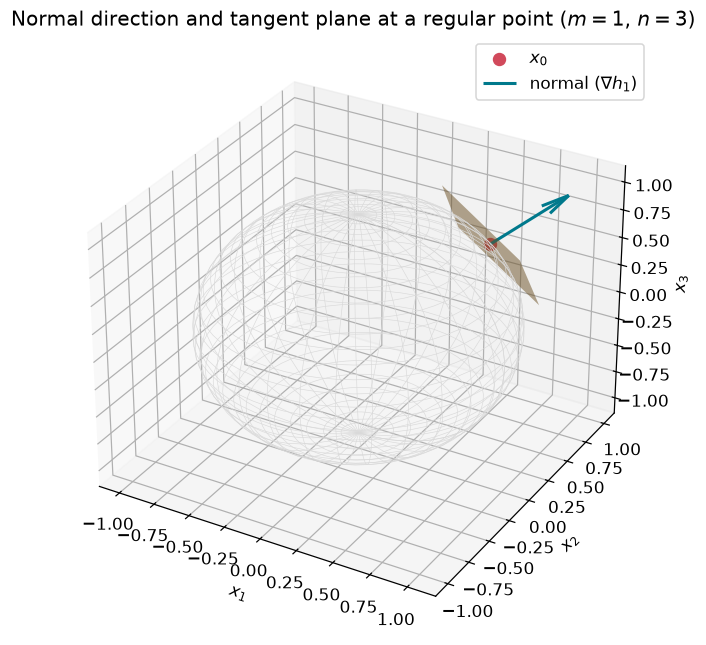

In [5]:
x0 = np.array([1, 1, 1]) / np.sqrt(3)  # a regular point on the unit sphere

def h1(x):
    return x[0]**2 + x[1]**2 + x[2]**2 - 1.0

def grad_h1(x):
    return 2 * x

n1 = grad_h1(x0)                      # spans the normal hyperplane (a line, since m=1)
tangent_basis = null_space(n1.reshape(1, 3))  # 2D tangent plane basis

print("normal direction  grad(h1)(x0) =", n1)
print("tangent-plane basis vectors:\n", tangent_basis)
print("orthogonality check (should be ~0):",
      [float(n1 @ tangent_basis[:, i]) for i in range(tangent_basis.shape[1])])

fig = plt.figure(figsize=(6.5, 6))
ax = fig.add_subplot(111, projection="3d")

u, v = np.mgrid[0:2 * np.pi:60j, 0:np.pi:30j]
sx, sy, sz = np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v)
ax.plot_wireframe(sx, sy, sz, color="0.85", linewidth=0.4)

ax.scatter(*x0, color=COLORS["optimum"], s=60, label="$x_0$")
ax.quiver(*x0, *(0.6 * n1 / np.linalg.norm(n1)), color=COLORS["boundary"], lw=2, label="normal ($\\nabla h_1$)")

s, t = np.meshgrid(np.linspace(-0.4, 0.4, 2), np.linspace(-0.4, 0.4, 2))
patch = x0[:, None, None] + s * tangent_basis[:, [0]][:, :, None] + t * tangent_basis[:, [1]][:, :, None]
ax.plot_surface(patch[0], patch[1], patch[2], color=COLORS["accent"], alpha=0.5)

ax.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$",
       title="Normal direction and tangent plane at a regular point ($m=1$, $n=3$)")
ax.legend()
plt.tight_layout()
plt.show()

h1(x0) = 2.22e-16, h2(x0) = 0.00e+00  (both ~0: x0 is feasible for both constraints)
rank(J) = 2 of 2 -> regular
tangent hyperplane dimension = 1  (expected n - m = 1)
tangent direction y = [-0.40824829 -0.40824829  0.81649658]
orthogonality check, grad(h1)^T y and grad(h2)^T y (should both be ~0): -2.220446049250313e-16 -5.551115123125783e-17


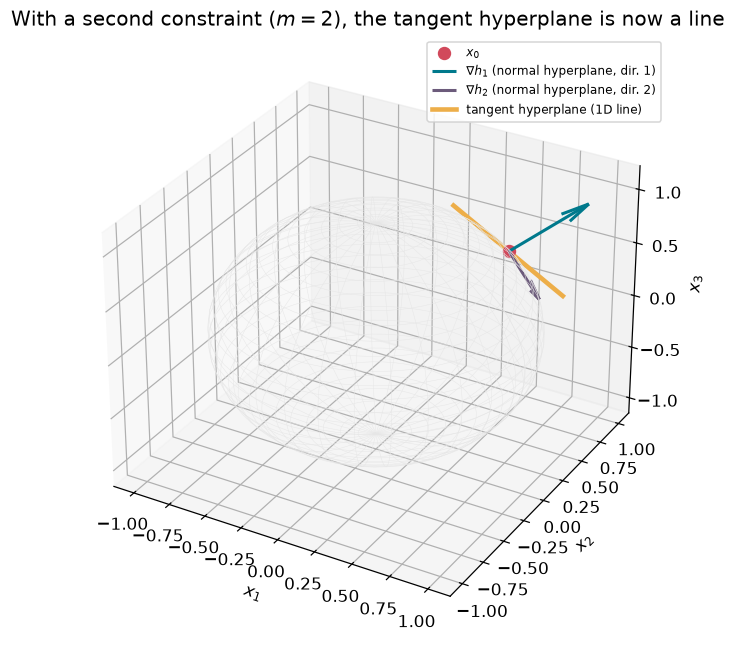

In [6]:
def h2(x):
    return x[0] - x[1]   # x0 has equal 1st/2nd components, so h2(x0) = 0 automatically

def grad_h2(x):
    return np.array([1.0, -1.0, 0.0])   # NOT parallel to grad_h1(x0) = 2*x0 = (const, const, const)

J2 = np.vstack([grad_h1(x0), grad_h2(x0)])
rank2 = np.linalg.matrix_rank(J2)
tangent_line = null_space(J2)   # should now be 1-D: n - m = 3 - 2 = 1

print(f"h1(x0) = {h1(x0):.2e}, h2(x0) = {h2(x0):.2e}  (both ~0: x0 is feasible for both constraints)")
print(f"rank(J) = {rank2} of 2 -> {'regular' if rank2 == 2 else 'NOT regular'}")
print(f"tangent hyperplane dimension = {tangent_line.shape[1]}  (expected n - m = {3 - 2})")

y = tangent_line[:, 0]
print("tangent direction y =", y)
print("orthogonality check, grad(h1)^T y and grad(h2)^T y (should both be ~0):",
      float(grad_h1(x0) @ y), float(grad_h2(x0) @ y))

fig = plt.figure(figsize=(6.5, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_wireframe(sx, sy, sz, color="0.9", linewidth=0.3)
ax.scatter(*x0, color=COLORS["optimum"], s=60, label="$x_0$")
ax.quiver(*x0, *(0.6 * grad_h1(x0) / np.linalg.norm(grad_h1(x0))), color=COLORS["boundary"], lw=2,
          label=r"$\nabla h_1$ (normal hyperplane, dir. 1)")
ax.quiver(*x0, *(0.6 * grad_h2(x0) / np.linalg.norm(grad_h2(x0))), color=COLORS["other"], lw=2,
          label=r"$\nabla h_2$ (normal hyperplane, dir. 2)")
ax.plot(*[x0[i] + np.linspace(-0.6, 0.6, 2) * y[i] for i in range(3)],
        color=COLORS["accent"], lw=3, label="tangent hyperplane (1D line)")
ax.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$",
       title="With a second constraint ($m=2$), the tangent hyperplane is now a line")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Both numerical checks confirm the remark from the slides: the tangent hyperplane is exactly the orthogonal complement of the normal hyperplane, and its dimension shrinks by one for every independent active constraint added ($p=n-m$), exactly as in Section 2's 2D circle/line pictures - just one dimension up.

---
## Takeaways

1. Lumping active inequalities with the equalities turns a general NLP locally into $h(x)=0$; the degrees of freedom left over are $p=n-m$.
2. $n>m$ (curve/surface), $n=m$ (isolated points), $n<m$ (generically inconsistent) are the three qualitatively different cases - and matter throughout the rest of the lecture, which only makes sense in the $n>m$ case.
3. Regularity (LICQ) is a *linear independence of gradients* condition, checked with `numpy.linalg.matrix_rank` on the active-constraint Jacobian - not "$\nabla g$ is square and invertible", which does not even make sense unless $m=n$.
4. The normal hyperplane (span of active gradients) and tangent hyperplane (its orthogonal complement, feasible directions) are dual descriptions of the same regular point; the reduced-gradient and Lagrangian derivations in the next two notebooks both live on the tangent hyperplane.
5. At an irregular point, the active gradients become linearly dependent - the cusp example here is the same one used in `L08_kkt_conditions.ipynb` to show that the KKT stationarity equation can become unsolvable.

## Optional exercises

1. Add a *third* generic plane constraint to the $m=2,n=3$ sphere example so that $m=3=n$. Solve for the (generically unique, isolated) feasible point in closed form and verify it numerically.
2. At the cusp point $x^*=(1,0)$ from Section 3, compute the *normal* hyperplane (span of $\nabla g_1,\nabla g_2$) directly - what dimension does it actually have, versus the dimension you would expect if the point were regular?
3. Pick your own quadratic equality constraint in $\mathbb{R}^3$ and a point on it; verify numerically, as in Section 4, that a randomly generated in-tangent-plane direction $y$ satisfies $h(x+\epsilon y) = O(\epsilon^2)$ for small $\epsilon$ (i.e. it only violates the constraint to second order).